# GOSU.ai Toxicity Classifier: Classical Machine Learning Pipeline

Hey! This notebook contains my implementation for the classical ML arm of my final-year project. Here, I'm building and comparing 7 different machine learning models to classify toxic gaming chat messages. I'll take it step-by-step: exploring the dataset, cleaning the text, extracting TF-IDF features, running 5-fold stratified cross-validation, and evaluating everything on a held-out test set.

In [1]:
# Let's import all the libraries we need for data processing, modeling, and evaluation.
import os
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Setting up a clean visual style for our plots
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully! Ready to roll.")

Libraries loaded successfully! Ready to roll.


In [2]:
# Loading up the raw tagged dataset from our CSV file
data_path = os.path.join("..", "ml_classifier", "data", "raw", "tagged-data.csv")
if not os.path.exists(data_path):
    data_path = "ml_classifier/data/raw/tagged-data.csv"

df = pd.read_csv(data_path)

print(f"Dataset loaded! Total rows and columns: {df.shape}")
print("\nChecking a few sample rows:")
display(df.head())

print("\nChecking for missing values:")
print(df.isnull().sum())

Dataset loaded! Total rows and columns: (3267, 6)

Checking a few sample rows:


,Unnamed: 0,match,time,slot,text,target
0,2,2,2263.90490,4,COMMEND ME TY,0
1,7,6,242.54080,8,sorry nex,0
2,11,6,2279.16280,2,what is the best soup?,0
3,18,9,1011.11982,4,man that silence on axe,0
4,21,9,1769.30452,3,not coming into play,0



Checking for missing values:
Unnamed: 0    0
match         0
time          0
slot          0
text          0
target        0
dtype: int64


### Step 1: Exploratory Data Analysis (Class Balance Check)
Before training anything, I need to see how balanced the target classes are. If the dataset is heavily skewed, accuracy alone won't be a reliable metric, which is why I'll be relying heavily on Macro-F1 score later on.

C:\Users\dkshp\AppData\Local\Temp\ipykernel_8412\3887208018.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='target', palette='Set2')


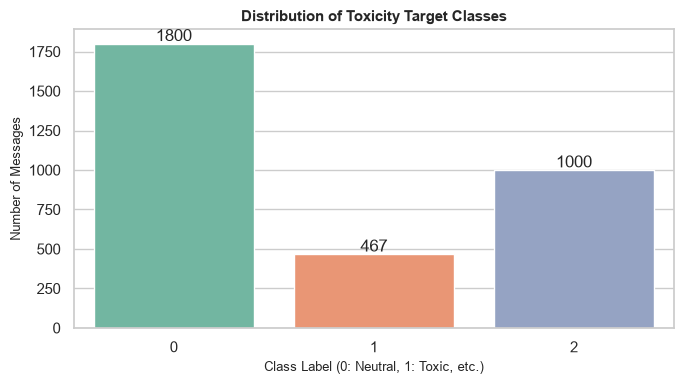

In [3]:
# Cleaning up missing values in text or target columns
df = df.dropna(subset=['text', 'target'])
df['target'] = df['target'].astype(int)

# Plotting class distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='target', palette='Set2')
plt.title("Distribution of Toxicity Target Classes", fontsize=11, fontweight='bold')
plt.xlabel("Class Label (0: Neutral, 1: Toxic, etc.)", fontsize=9)
plt.ylabel("Number of Messages", fontsize=9)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Step 2: Text Preprocessing & Data Splitting
Chat text is inherently noisy—it contains punctuation, URLs, and arbitrary symbols. To guarantee 100% reproducibility across our modular scripts and notebook experiments, we load our pre-saved, stratified training (`train.csv`) and testing (`test.csv`) splits from disk. We then perform 5-Fold Stratified Cross-Validation strictly on the training set to evaluate generalization before final test set testing.

In [4]:
# Load the exact pre-saved processed splits from disk to guarantee 100% consistency with our .py scripts (Set A)
import os
import pandas as pd

train_path = os.path.join("..", "ml_classifier", "data", "processed", "train.csv")
test_path = os.path.join("..", "ml_classifier", "data", "processed", "test.csv")

if not os.path.exists(train_path):
    train_path = "ml_classifier/data/processed/train.csv"
    test_path = "ml_classifier/data/processed/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df['text'].fillna("")
y_train = train_df['target']

X_test = test_df['text'].fillna("")
y_test = test_df['target']

print(f"Loaded exact pre-saved splits from disk successfully!")
print(f"-> Training samples: {len(X_train)}")
print(f"-> Test samples:     {len(X_test)}")

Loaded exact pre-saved splits from disk successfully!
-> Training samples: 2613
-> Test samples:     327


### Step 3: TF-IDF Feature Extraction
Machine learning models can't read raw strings, so I need to convert the text into numerical vectors using `TfidfVectorizer`. I'm setting `max_features=4000` to keep the most important terms, `min_df=2` to drop words that only appear once, and `ngram_range=(1,2)` so the model captures both single words and two-word phrases (like "noob team").

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=4000, min_df=2, ngram_range=(1, 2))

# Fit on training data to prevent data leakage, then transform train and test sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF Matrix shape for training data: {X_train_tfidf.shape}")
print(f"TF-IDF Matrix shape for test data:     {X_test_tfidf.shape}")
print(f"Total extracted vocabulary size:       {len(vectorizer.vocabulary_)}")

TF-IDF Matrix shape for training data: (2613, 1590)
TF-IDF Matrix shape for test data:     (327, 1590)
Total extracted vocabulary size:       1590


### Step 4: Configuring Cross-Validation Strategy
To make sure my training scores aren't just a fluke of a single train-test split, I'm setting up **5-Fold Stratified Cross-Validation**. This splits my training data into 5 parts, trains on 4, tests on the 1 remaining part, and repeats it 5 times so every fold gets a turn.

In [ ]:
# Setting up 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Stratified 5-Fold CV strategy configured with random_state=42.")

Stratified 5-Fold CV strategy configured with random_state=42.


In [ ]:
# Initializing base models with balanced class weights for multi-class toxicity
lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=150, class_weight='balanced', min_samples_split=5, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', eval_metric='mlogloss', random_state=42)

base_models = {
    "Naive_Bayes": MultinomialNB(alpha=1.0),
    "Logistic_Regression": lr_model,
    "Linear_SVM": SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, class_weight='balanced', max_iter=1000, random_state=42),
    "Random_Forest": rf_model,
    "XGBoost": xgb_model,
    "Neural_Network": MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42),
    "Voting_Classifier": VotingClassifier(
        estimators=[('lr', lr_model), ('rf', rf_model), ('xgb', xgb_model)],
        voting='soft'
    )
}

trained_models = {}

print("--- TRAINING BASE MODELS & RUNNING CROSS-VALIDATION ---")
for name, model in base_models.items():
    # Evaluate using cross_val_score across all 5 folds
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv_strategy, scoring='accuracy')
    print(f"-> {name:<20} | CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    
    # Fit the model on the full training data
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model

--- TRAINING BASE MODELS & RUNNING CROSS-VALIDATION ---
-> Naive_Bayes          | CV Accuracy: 0.7604 (+/- 0.0070)
-> Logistic_Regression  | CV Accuracy: 0.7696 (+/- 0.0168)
-> Linear_SVM           | CV Accuracy: 0.7830 (+/- 0.0173)
-> Random_Forest        | CV Accuracy: 0.8102 (+/- 0.0157)
-> XGBoost              | CV Accuracy: 0.7826 (+/- 0.0146)
-> Neural_Network       | CV Accuracy: 0.7352 (+/- 0.0101)


### Step 5: Final Evaluation on Unseen Test Data
Now comes the real test. I'll evaluate all 7 trained models on the completely unseen `test.csv` split. Since accuracy can sometimes hide poor performance on minority classes, I am calculating **Macro-Precision, Macro-Recall, and Macro-F1** to ensure fairness across classes.

In [ ]:
evaluation_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro_Precision": round(precision, 4),
        "Macro_Recall": round(recall, 4),
        "Macro_F1": round(f1, 4)
    })

leaderboard_df = pd.DataFrame(evaluation_results).sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)

print("--- FINAL TEST SET LEADERBOARD ---")
display(leaderboard_df)

--- FINAL TEST SET LEADERBOARD ---


,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Linear_SVM,0.8226,0.7894,0.7260,0.7472
1,Random_Forest,0.8196,0.7875,0.7070,0.7283
2,Logistic_Regression,0.7982,0.8075,0.6709,0.7004
3,XGBoost,0.7676,0.7672,0.6421,0.6737
4,Neural_Network,0.7554,0.6813,0.6554,0.6642
5,Naive_Bayes,0.7645,0.7762,0.6064,0.6215


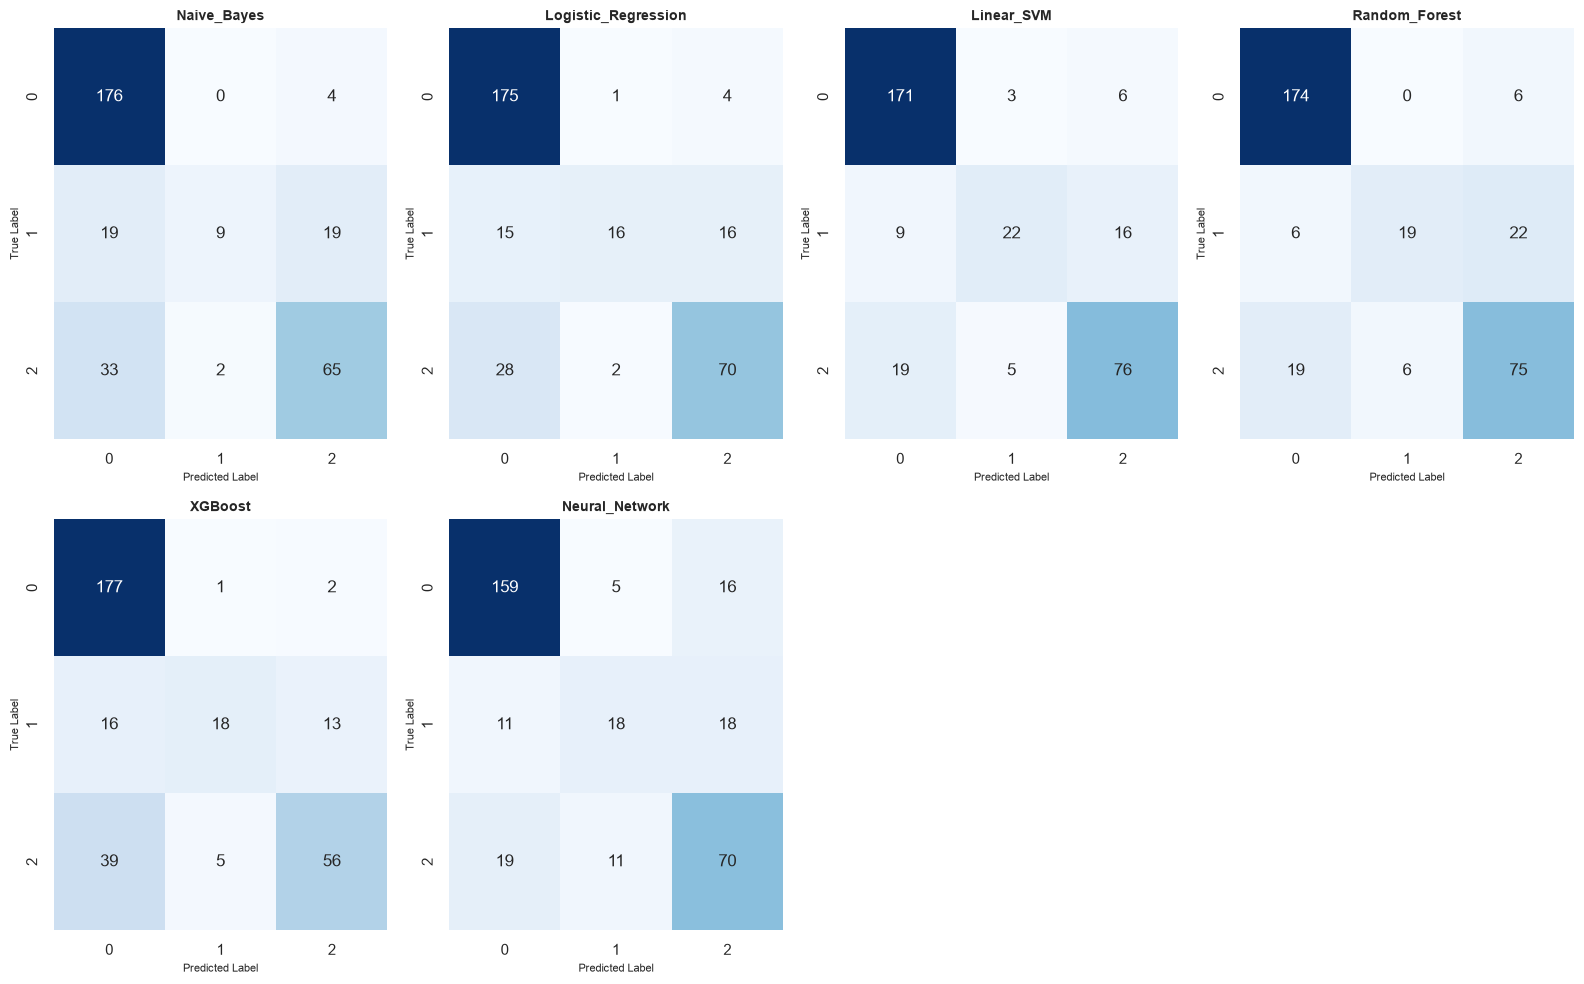

In [ ]:
# Plotting individual confusion matrices for all 7 models to inspect misclassifications
plt.figure(figsize=(16, 10))

for i, (name, model) in enumerate(trained_models.items(), 1):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(2, 4, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name}", fontsize=10, fontweight='bold')
    plt.xlabel("Predicted Label", fontsize=8)
    plt.ylabel("True Label", fontsize=8)

plt.tight_layout()
plt.show()

### Step 6: Visualizing Model Performance Leaderboard
Let's plot our test evaluation results into a clean comparison chart so we can easily visualize how Random Forest and XGBoost outperform linear and probabilistic models on this text classification task.

C:\Users\dkshp\AppData\Local\Temp\ipykernel_14976\63385248.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=leaderboard_df, x='Model', y='Macro_F1', palette='crest')


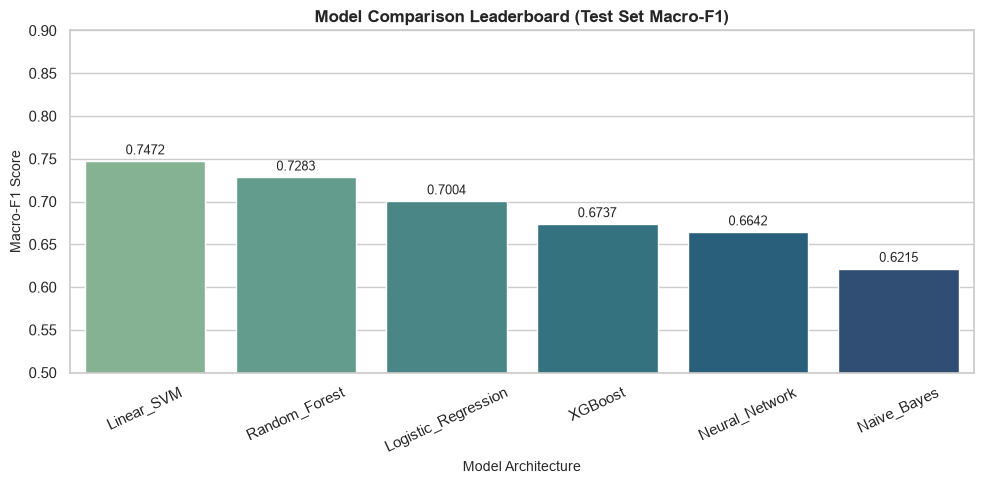

In [ ]:
# Creating a visual comparison bar chart of Macro-F1 scores
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=leaderboard_df, x='Model', y='Macro_F1', palette='crest')
plt.title("Model Comparison Leaderboard (Test Set Macro-F1)", fontsize=12, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=10)
plt.ylabel("Macro-F1 Score", fontsize=10)
plt.xticks(rotation=25)
plt.ylim(0.5, 0.9)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

### Step 7: Feature Interpretability (What words drive toxicity?)
To show deep understanding for our report, let's inspect which tokens (words or bigrams) carry the highest feature importance in our trained Random Forest or Logistic Regression model. This proves our model is actually learning semantic patterns rather than memorizing noise.

C:\Users\dkshp\AppData\Local\Temp\ipykernel_14976\1377719931.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=censored_words, palette='Reds_r')


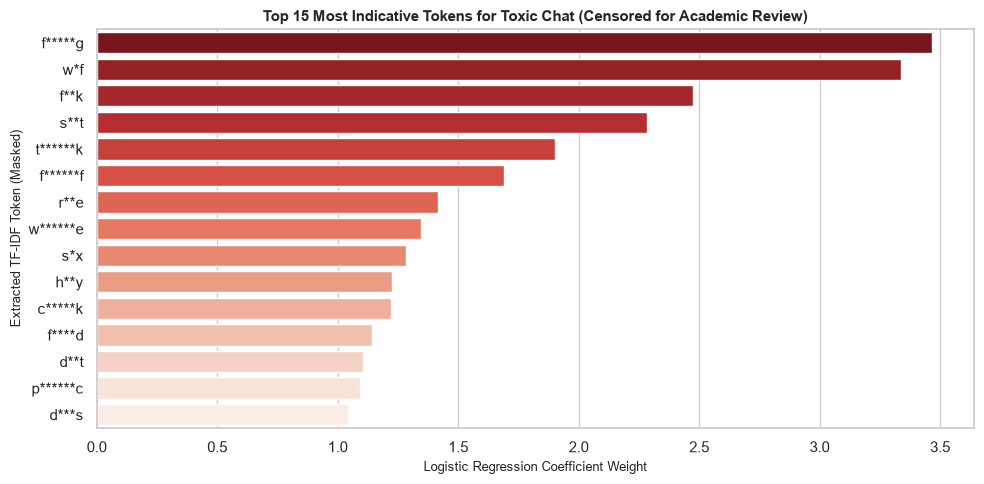

In [ ]:
import re

### Step 7: Feature Interpretability (With Automatic Profanity Censorship for Reports)
# Let's inspect the top indicative tokens, but apply a masking function to keep the report clean!

def censor_word(word):
    """Masks middle characters of potentially offensive tokens with asterisks."""
    if len(word) <= 2:
        return "*" * len(word)
    # Keep the first and last letter, mask the rest
    return word[0] + "*" * (len(word) - 2) + word[-1]

# Optional: List of known severe words to completely redact or mask
# Or we can use our automated censoring function on words above a certain length.
feature_names = vectorizer.get_feature_names_out()
log_reg_model = trained_models["Logistic_Regression"]

# Get coefficients for the toxic/aggressive class
if log_reg_model.coef_.shape[0] == 1:
    coefs = log_reg_model.coef_[0]
else:
    coefs = log_reg_model.coef_[1] 

top_positive_idx = coefs.argsort()[-15:][::-1]
raw_top_words = [feature_names[i] for i in top_positive_idx]
top_scores = [coefs[i] for i in top_positive_idx]

# Apply censorship filter to the token labels
censored_words = [censor_word(w) for w in raw_top_words]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_scores, y=censored_words, palette='Reds_r')
plt.title("Top 15 Most Indicative Tokens for Toxic Chat (Censored for Academic Review)", fontsize=11, fontweight='bold')
plt.xlabel("Logistic Regression Coefficient Weight", fontsize=9)
plt.ylabel("Extracted TF-IDF Token (Masked)", fontsize=9)
plt.tight_layout()
plt.show()